In [ ]:
# ----------------------------------------------------
# Title: Rain Tomorrow Prediction Using K-Nearest Neighbors (KNN)
# Author: Ehsan Saleh
# Course: Supervised Machine Learning
# Instructor: Dr. Ehsan Nazerfard
# Program: MCI AI Bootcamp (Generative AI with a Focus on Image Processing and Analysis)
# ----------------------------------------------------

import pandas as pd
from google.colab import drive

#### dar in ghesmat ma RainToday va RainTomorrow ro ke harkodum NA boodan ro hazf kardim ###

# 1. Mount Google Drive to the Colab environment
# This will ask for your permission to access your Google Drive
drive.mount('/content/drive')

# 2. Define the path to your file inside Google Drive
# NOTE: Update 'My Drive/BOM.csv' if your file is inside a specific folder
file_path = '/content/drive/MyDrive/MCI-AI-Bootcamp/Supervised ML/Question 2/BOM.csv'

try:
    # 3. Read the file from Google Drive
    df = pd.read_csv(file_path)
    initial_rows = len(df)

    # 4. Drop rows where either 'RainToday' or 'RainTomorrow' is NA
    df_cleaned = df.dropna(subset=['RainToday', 'RainTomorrow'], how='any')

    # 5. Calculate the number of deleted rows
    final_rows = len(df_cleaned)
    deleted_rows = initial_rows - final_rows

    # 6. Save the cleaned dataset back to your Google Drive
    output_path = '/content/drive/MyDrive/MCI-AI-Bootcamp/Supervised ML/Question 2/BOM_cleaned.csv'
    df_cleaned.to_csv(output_path, index=False)

    # 7. Print the final execution report
    print("-" * 50)
    print(f"Initial rows:      {initial_rows:,}")
    print(f"Deleted rows:      {deleted_rows:,}")
    print(f"Remaining rows:    {final_rows:,}")
    print("-" * 50)
    print(f"Cleaned file successfully saved back to Drive as: '{output_path}'")

except FileNotFoundError:
    print(f"Error: Could not find the file at '{file_path}'. Please make sure the file name and path are correct.")

Mounted at /content/drive
--------------------------------------------------
Initial rows:      145,460
Deleted rows:      4,673
Remaining rows:    140,787
--------------------------------------------------
Cleaned file successfully saved back to Drive as: '/content/drive/MyDrive/MCI-AI-Bootcamp/Supervised ML/Question 2/BOM_cleaned.csv'


In [ ]:
# 1. Define the path to the final dataset from the previous step
file_path = '/content/drive/MyDrive/MCI-AI-Bootcamp/Supervised ML/Question 2/BOM_cleaned.csv'

try:
    # 2. Read the dataset
    df = pd.read_csv(file_path)
    total_rows = len(df)

    # 3. Drop 'Location' just for this analysis as requested
    df_analysis = df.drop(columns=['Location'], errors='ignore')

    # 4. Calculate missing values and percentages
    missing_count = df_analysis.isnull().sum()
    missing_percentage = (missing_count / total_rows) * 100

    # 5. Create a summary DataFrame
    missing_summary = pd.DataFrame({
        'Missing Count': missing_count,
        'Percentage (%)': missing_percentage
    })

    # 6. Sort by highest missing percentage
    missing_summary = missing_summary.sort_values(by='Percentage (%)', ascending=False)

    # 7. Print the results
    print("-" * 50)
    print(f"Total Rows in Dataset: {total_rows:,}")
    print("-" * 50)
    print(missing_summary.to_string(formatters={'Percentage (%)': '{:,.2f}%'.format}))
    print("-" * 50)

except FileNotFoundError:
    print(f"Error: Could not find the file at '{file_path}'. Please check the path.")

--------------------------------------------------
Total Rows in Dataset: 140,787
--------------------------------------------------
               Missing Count Percentage (%)
Sunshine               66805         47.45%
Evaporation            59694         42.40%
Cloud3pm               56094         39.84%
Cloud9am               52625         37.38%
Pressure3pm            13769          9.78%
Pressure9am            13743          9.76%
WindDir9am              9660          6.86%
WindGustDir             9163          6.51%
WindGustSpeed           9105          6.47%
WindDir3pm              3670          2.61%
Humidity3pm             3501          2.49%
Temp3pm                 2624          1.86%
WindSpeed3pm            2531          1.80%
Humidity9am             1517          1.08%
WindSpeed9am            1055          0.75%
Temp9am                  656          0.47%
MinTemp                  468          0.33%
MaxTemp                  307          0.22%
Rainfall                   0   

In [ ]:

#### dar in marhale sotunhaye "Date و WindDir9am / WindDir3pm / WindGustDir و Temp9am / Temp3pm و Evaporation و Sunshine" ro hazf mikonim va file jadid ro save mikonim
#### hamchenin sotune "cloude" ro ham hazf kardim chra ke tedad e NA ziyadi dasht

# 1. Define the paths (Update the file name if you are using the cleaned version)
input_path = '/content/drive/MyDrive/MCI-AI-Bootcamp/Supervised ML/Question 2/BOM_cleaned.csv'
output_path = '/content/drive/MyDrive/MCI-AI-Bootcamp/Supervised ML/Question 2/BOM_final.csv'

try:
    # 2. Read the dataset
    df = pd.read_csv(input_path)
    print(f"Original shape (Rows, Columns): {df.shape}")

    # 3. List of columns to drop as requested
    columns_to_drop = [
        'Date', 'WindDir9am', 'WindDir3pm', 'WindGustDir',
        'Temp9am', 'Temp3pm', 'Evaporation', 'Sunshine',
        'Cloud9am', 'Cloud3pm'  # Added cloud columns here
    ]

    # 4. Drop the columns (errors='ignore' prevents crashing if a column is already deleted)
    df_final = df.drop(columns=columns_to_drop, errors='ignore')

    # 5. Save the new dataset back to Google Drive
    df_final.to_csv(output_path, index=False)

    # 6. Print the final report
    print("-" * 50)
    print(f"Columns successfully dropped: {columns_to_drop}")
    print(f"New shape (Rows, Columns):      {df_final.shape}")
    print("-" * 50)
    print(f"Final dataset successfully saved to Drive as: '{output_path}'")

except FileNotFoundError:
    print(f"Error: Could not find the file at '{input_path}'. Please check the path.")

Original shape (Rows, Columns): (140787, 23)
--------------------------------------------------
Columns successfully dropped: ['Date', 'WindDir9am', 'WindDir3pm', 'WindGustDir', 'Temp9am', 'Temp3pm', 'Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']
New shape (Rows, Columns):      (140787, 13)
--------------------------------------------------
Final dataset successfully saved to Drive as: '/content/drive/MyDrive/MCI-AI-Bootcamp/Supervised ML/Question 2/BOM_final.csv'


In [ ]:
###### inja mikhaym bebinim ke dade ma cheghadr imbalance hast

# 1. Define the path to your final cleaned dataset
file_path = '/content/drive/MyDrive/MCI-AI-Bootcamp/Supervised ML/Question 2/BOM_final.csv'

try:
    # 2. Read the dataset
    df = pd.read_csv(file_path)
    total_valid_rows = len(df)

    # 3. Count the occurrences of 'Yes' and 'No' in RainTomorrow
    class_counts = df['RainTomorrow'].value_counts()
    class_percentages = df['RainTomorrow'].value_counts(normalize=True) * 100

    # 4. Create a clean summary DataFrame
    imbalance_summary = pd.DataFrame({
        'Total Count': class_counts,
        'Percentage (%)': class_percentages
    })

    # 5. Print the execution report
    print("-" * 50)
    print(f"Target Variable: RainTomorrow")
    print(f"Total Evaluated Rows: {total_valid_rows:,}")
    print("-" * 50)
    print(imbalance_summary.to_string(formatters={'Percentage (%)': '{:,.2f}%'.format}))
    print("-" * 50)

except FileNotFoundError:
    print(f"Error: Could not find the file at '{file_path}'. Please check the path.")

--------------------------------------------------
Target Variable: RainTomorrow
Total Evaluated Rows: 140,787
--------------------------------------------------
              Total Count Percentage (%)
RainTomorrow                            
No                 109586         77.84%
Yes                 31201         22.16%
--------------------------------------------------


In [ ]:
#### tuye in bakhsh mavaredi ke na hastand ro por mikonim

# 1. Define paths
input_path = '/content/drive/MyDrive/MCI-AI-Bootcamp/Supervised ML/Question 2/BOM_final.csv'
output_path = '/content/drive/MyDrive/MCI-AI-Bootcamp/Supervised ML/Question 2/BOM_imputed.csv'

try:
    # 2. Read dataset
    df = pd.read_csv(input_path)

    # 3. Identify numerical columns (excluding 'Location', 'RainToday', and 'RainTomorrow')
    # RainToday and RainTomorrow will be encoded separately if needed, or are already cleaned.
    exclude_cols = ['Location', 'RainToday', 'RainTomorrow']
    numerical_cols = [col for col in df.columns if col not in exclude_cols]

    print("--- [STEP 1] Missing Values Before Imputation ---")
    total_rows = len(df)
    for col in numerical_cols:
        na_count = df[col].isnull().sum()
        na_pct = (na_count / total_rows) * 100
        print(f"Column '{col}': {na_count:,} missing values ({na_pct:.2f}%)")

    print("\n--- [STEP 2] Imputing Missing Values using Location Median ---")
    # 4. Fill NA for each column based on the median of its respective Location
    for col in numerical_cols:
        # Group by Location and fill NA with median of that Location
        df[col] = df.groupby('Location')[col].transform(lambda x: x.fillna(x.median()))

        # Fallback: If a whole location has missing values for a feature, fill with global median
        global_median = df[col].median()
        df[col] = df[col].fillna(global_median)

    print("Imputation completed successfully!")

    print("\n--- [STEP 3] Verifying Missing Values After Imputation ---")
    # 5. Double check to ensure 0 NAs remain
    for col in numerical_cols:
        na_count = df[col].isnull().sum()
        print(f"Column '{col}': {na_count} missing values")

    # 6. Save the fully imputed dataset
    df.to_csv(output_path, index=False)
    print(f"\nFinal imputed dataset successfully saved to: '{output_path}'")

except FileNotFoundError:
    print(f"Error: Could not find the file at '{input_path}'. Please check the path.")

--- [STEP 1] Missing Values Before Imputation ---
Column 'MinTemp': 468 missing values (0.33%)
Column 'MaxTemp': 307 missing values (0.22%)
Column 'Rainfall': 0 missing values (0.00%)
Column 'WindGustSpeed': 9,105 missing values (6.47%)
Column 'WindSpeed9am': 1,055 missing values (0.75%)
Column 'WindSpeed3pm': 2,531 missing values (1.80%)
Column 'Humidity9am': 1,517 missing values (1.08%)
Column 'Humidity3pm': 3,501 missing values (2.49%)
Column 'Pressure9am': 13,743 missing values (9.76%)
Column 'Pressure3pm': 13,769 missing values (9.78%)

--- [STEP 2] Imputing Missing Values using Location Median ---
Imputation completed successfully!

--- [STEP 3] Verifying Missing Values After Imputation ---
Column 'MinTemp': 0 missing values
Column 'MaxTemp': 0 missing values
Column 'Rainfall': 0 missing values
Column 'WindGustSpeed': 0 missing values
Column 'WindSpeed9am': 0 missing values
Column 'WindSpeed3pm': 0 missing values
Column 'Humidity9am': 0 missing values
Column 'Humidity3pm': 0 miss

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. Define input and output paths
input_path = '/content/drive/MyDrive/MCI-AI-Bootcamp/Supervised ML/Question 2/BOM_imputed.csv'
train_output_path = '/content/drive/MyDrive/MCI-AI-Bootcamp/Supervised ML/Question 2/BOM_train_ready.csv'
test_output_path = '/content/drive/MyDrive/MCI-AI-Bootcamp/Supervised ML/Question 2/BOM_test_ready.csv'

try:
    # 2. Read dataset
    df = pd.read_csv(input_path)

    # Encode Target variable (RainTomorrow) and RainToday to 0 and 1
    df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})
    if df['RainToday'].dtype == 'object':
        df['RainToday'] = df['RainToday'].map({'Yes': 1, 'No': 0})

    # 3. Separate Features (X) and Target (y)
    X = df.drop(columns=['RainTomorrow'])
    y = df['RainTomorrow']

    print(f"Original dataset shape: {df.shape}")

    # 4. Stratified Split based on 'Location' (80% Train, 20% Test)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=X['Location'],
        random_state=42
    )

    # 5. One-Hot Encoding for 'Location' column
    X_train_encoded = pd.get_dummies(X_train, columns=['Location'], drop_first=True)
    X_test_encoded = pd.get_dummies(X_test, columns=['Location'], drop_first=True)

    # Align columns to avoid missing column mismatches
    X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

    # 6. Normalize numerical features using MinMaxScaler (0 to 1)
    exclude_from_scaling = [col for col in X_train_encoded.columns if col.startswith('Location_')] + ['RainToday']
    numerical_features = [col for col in X_train_encoded.columns if col not in exclude_from_scaling]

    scaler = MinMaxScaler()

    # Fit on training data and transform both sets (Prevents Data Leakage)
    X_train_encoded[numerical_features] = scaler.fit_transform(X_train_encoded[numerical_features])
    X_test_encoded[numerical_features] = scaler.transform(X_test_encoded[numerical_features])

    # Convert to float to ensure uniform format
    X_train_final = X_train_encoded.astype(float)
    X_test_final = X_test_encoded.astype(float)

    # 7. Re-attach the target column (RainTomorrow) just for the saved Excel/CSV files
    train_to_save = X_train_final.copy()
    train_to_save['RainTomorrow'] = y_train

    test_to_save = X_test_final.copy()
    test_to_save['RainTomorrow'] = y_test

    # 8. Save the final datasets to Drive (Can be opened directly in Excel)
    train_to_save.to_csv(train_output_path, index=False)
    test_to_save.to_csv(test_output_path, index=False)

    print("-" * 60)
    print("--- Process Completed & Files Saved! ---")
    print(f"Train dataset saved to: {train_output_path} (Shape: {train_to_save.shape})")
    print(f"Test dataset saved to:  {test_output_path} (Shape: {test_to_save.shape})")
    print("-" * 60)
    print("Variables X_train_final, X_test_final, y_train, and y_test are ready in memory.")

except FileNotFoundError:
    print(f"Error: Could not find the file at '{input_path}'. Please check the path.")

Original dataset shape: (140787, 13)
------------------------------------------------------------
--- Process Completed & Files Saved! ---
Train dataset saved to: /content/drive/MyDrive/MCI-AI-Bootcamp/Supervised ML/Question 2/BOM_train_ready.csv (Shape: (112629, 60))
Test dataset saved to:  /content/drive/MyDrive/MCI-AI-Bootcamp/Supervised ML/Question 2/BOM_test_ready.csv (Shape: (28158, 60))
------------------------------------------------------------
Variables X_train_final, X_test_final, y_train, and y_test are ready in memory.


--- Starting Grid Search for Best K with DISTANCE WEIGHTING ---
Training Weighted KNN with K = 3 ... Test F1-Score: 0.5810
Training Weighted KNN with K = 5 ... Test F1-Score: 0.5873
Training Weighted KNN with K = 7 ... Test F1-Score: 0.5880
Training Weighted KNN with K = 9 ... Test F1-Score: 0.5914
Training Weighted KNN with K = 10 ... Test F1-Score: 0.5933
Training Weighted KNN with K = 11 ... Test F1-Score: 0.5892
Training Weighted KNN with K = 13 ... Test F1-Score: 0.5875

🏆 SUCCESS: The Best K (Weighted) is 10 with an F1-Score of 0.5933

--- Training Final Weighted Model ---
--- Evaluation with Custom Threshold (0.35) ---
              precision    recall  f1-score   support

     No Rain       0.89      0.89      0.89     21937
        Rain       0.63      0.63      0.63      6221

    accuracy                           0.84     28158
   macro avg       0.76      0.76      0.76     28158
weighted avg       0.84      0.84      0.84     28158



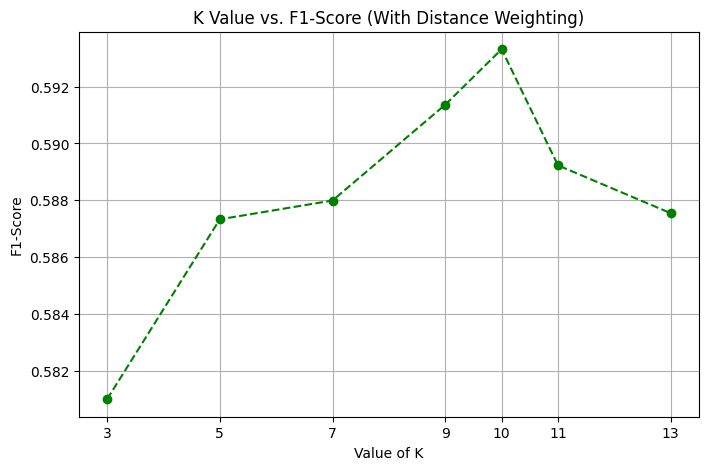

In [ ]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, classification_report

# 1. Define the values of K to test (Using odd numbers to avoid ties)
k_values = [3, 5, 7, 9, 10, 11, 13, ]
f1_scores = []

print("--- Starting Grid Search for Best K with DISTANCE WEIGHTING ---")

# 2. Loop through each K value
for k in k_values:
    print(f"Training Weighted KNN with K = {k} ... ", end="")

    # weights='distance' assigns higher weight to closer neighbors,
    # which heavily combats the class imbalance issue.
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1)

    # Train the model
    knn.fit(X_train_final, y_train)

    # Predict on Test set
    y_pred = knn.predict(X_test_final)

    # Calculate F1-score (average='binary' focuses on class 1: Rain)
    score = f1_score(y_test, y_pred, average='binary')
    f1_scores.append(score)

    print(f"Test F1-Score: {score:.4f}")

# 3. Find the best K
best_index = f1_scores.index(max(f1_scores))
best_k = k_values[best_index]
best_f1 = f1_scores[best_index]

print("\n" + "="*50)
print(f"🏆 SUCCESS: The Best K (Weighted) is {best_k} with an F1-Score of {best_f1:.4f}")
print("="*50 + "\n")

#
print("--- Training Final Weighted Model ---")
final_knn = KNeighborsClassifier(n_neighbors=best_k, weights='distance', n_jobs=-1)
final_knn.fit(X_train_final, y_train)

# 1. Predict probabilities instead of hard classes (0 or 1)
# This gets the probability of being 'Rain' (class 1)
y_probs = final_knn.predict_proba(X_test_final)[:, 1]

# 2. Set a lower threshold (e.g., 0.35 instead of 0.5)
custom_threshold = 0.35
y_pred_custom = np.where(y_probs >= custom_threshold, 1, 0)

# 3. Print the new report to compare
print(f"--- Evaluation with Custom Threshold ({custom_threshold}) ---")
print(classification_report(y_test, y_pred_custom, target_names=['No Rain', 'Rain']))

# 5. Plot the K vs F1-Score graph
plt.figure(figsize=(8, 5))
plt.plot(k_values, f1_scores, marker='o', linestyle='--', color='g')
plt.title('K Value vs. F1-Score (With Distance Weighting)')
plt.xlabel('Value of K')
plt.ylabel('F1-Score')
plt.xticks(k_values)
plt.grid(True)
plt.show()